1. Setup Awal

In [7]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Voting Classifiers

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Membuat dataset moons
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Mendefinisikan tiga model yang berbeda
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(gamma="scale", probability=True, random_state=42) # probability=True untuk soft voting

# Membuat Voting Classifier
# voting='hard' akan menggunakan prediksi mayoritas
# voting='soft' akan menggunakan rata-rata probabilitas
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='soft'
)

# Melatih semua model
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.92


 3. Bagging dan Pasting

Akurasi Bagging Classifier: 0.912


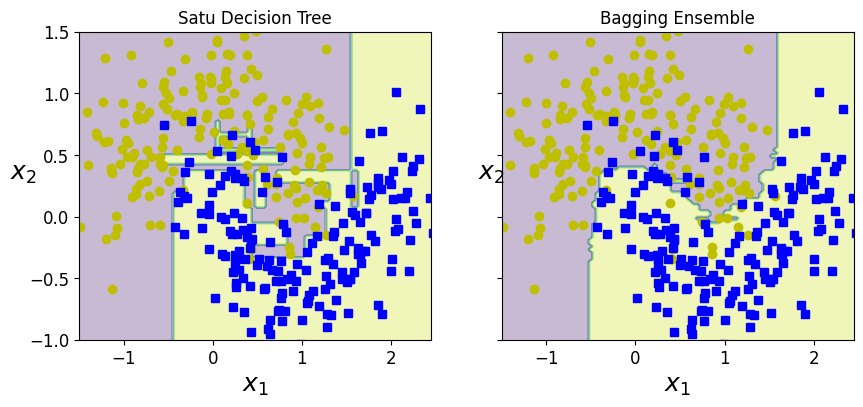

In [9]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# CATATAN: n_estimators dikurangi dari 500 ke 50 agar cepat
# Bagging: bootstrap=True
# Pasting: bootstrap=False
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=100,
    bootstrap=True,
    random_state=42
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

print("Akurasi Bagging Classifier:", accuracy_score(y_test, y_pred))

# Fungsi untuk plot decision boundary (dari chapter sebelumnya)
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.45, -1, 1.5]):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap='viridis')
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

# Membandingkan decision boundary dari satu Decision Tree vs Bagging Ensemble
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

fig, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X_train, y_train)
plt.title("Satu Decision Tree")
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X_train, y_train)
plt.title("Bagging Ensemble")
plt.show()

4. Out-of-Bag (OOB) Evaluation

In [10]:
# Melatih Bagging Classifier dengan oob_score=True
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=500, # Menggunakan n_estimators lebih besar untuk oob score yang stabil
    bootstrap=True,
    oob_score=True, # Meminta untuk melakukan evaluasi OOB
    random_state=40
)
bag_clf.fit(X_train, y_train)

# Menampilkan OOB score
print("OOB Score:", bag_clf.oob_score_)

# Membandingkan dengan akurasi pada test set
y_pred = bag_clf.predict(X_test)
print("Akurasi Test Set:", accuracy_score(y_test, y_pred))

OOB Score: 0.8986666666666666
Akurasi Test Set: 0.912


5. Random Forests

In [11]:
from sklearn.ensemble import RandomForestClassifier

# CATATAN: n_estimators dikurangi dari 500 ke 50 agar cepat
rnd_clf = RandomForestClassifier(n_estimators=50, max_leaf_nodes=16, random_state=42)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))

# Menampilkan tingkat kepentingan fitur (feature importance)
from sklearn.datasets import load_iris
iris = load_iris()
rnd_clf_iris = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf_iris.fit(iris["data"], iris["target"])

print("\nFeature importances untuk dataset Iris:")
for name, score in zip(iris["feature_names"], rnd_clf_iris.feature_importances_):
    print(name, score)

Akurasi Random Forest: 0.92

Feature importances untuk dataset Iris:
sepal length (cm) 0.11249225099876375
sepal width (cm) 0.02311928828251033
petal length (cm) 0.4410304643639577
petal width (cm) 0.4233579963547682


6. Boosting - AdaBoost

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


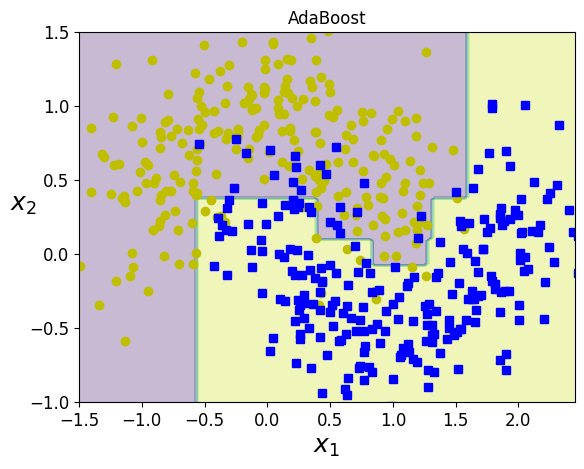

In [12]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    algorithm="SAMME",
    learning_rate=0.5,
    random_state=42
)
ada_clf.fit(X_train, y_train)

plot_decision_boundary(ada_clf, X, y)
plt.title("AdaBoost")
plt.show()

 7. Boosting - Gradient Boosting

In [13]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Membuat data kuadratik acak
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

# Melatih model Gradient Boosting Regressor
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, learning_rate=0.1, random_state=42)
gbrt.fit(X, y)

# Mencari jumlah pohon optimal menggunakan early stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, random_state=49)
gbrt_early = GradientBoostingRegressor(max_depth=2, n_estimators=120, random_state=42)
gbrt_early.fit(X_train, y_train)

errors = [mean_squared_error(y_val, y_pred)
          for y_pred in gbrt_early.staged_predict(X_val)]
bst_n_estimators = np.argmin(errors) + 1

print("Jumlah pohon optimal:", bst_n_estimators)

# Contoh penggunaan XGBoost
# CATATAN: Mungkin perlu install library: pip install xgboost
import xgboost
xgb_reg = xgboost.XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train)
y_pred = xgb_reg.predict(X_val)

print("XGBoost selesai dilatih.")

Jumlah pohon optimal: 56
XGBoost selesai dilatih.


Penjelasan Kode
Bagian 1. Setup Awal: Seperti biasa, bagian ini mempersiapkan library yang akan digunakan.

Bagian 2. Voting Classifiers: Ini adalah teknik ensemble paling sederhana. Idenya adalah melatih beberapa model yang berbeda (misalnya Regresi Logistik, Random Forest, dan SVM) pada data yang sama. Saat membuat prediksi, hasil dari setiap model akan "divoting" (diambil suara mayoritasnya).

Hard Voting: Prediksi akhir adalah kelas yang paling banyak dipilih oleh model-model individu.

Soft Voting: Setiap model memberikan probabilitas untuk setiap kelas. Probabilitas ini dirata-ratakan, dan kelas dengan probabilitas rata-rata tertinggi menjadi prediksi akhir. Biasanya soft voting memberikan hasil yang lebih baik.

Bagian 3. Bagging dan Pasting: Teknik ini juga melatih beberapa model, tetapi menggunakan algoritma yang sama (misalnya, semua Decision Tree). Perbedaannya adalah setiap model dilatih pada bagian acak yang berbeda dari data latih.

Pasting: Setiap model dilatih pada subset data yang diambil tanpa pengembalian (sampling without replacement).

Bagging (Bootstrap Aggregating): Setiap model dilatih pada subset data yang diambil dengan pengembalian (sampling with replacement). Artinya, satu data yang sama bisa muncul beberapa kali dalam satu subset. Bagging cenderung menghasilkan model yang lebih baik karena variasi subset datanya lebih tinggi.

Bagian 4. Out-of-Bag (OOB) Evaluation: Ini adalah fitur keren dari Bagging. Karena sampling dilakukan dengan pengembalian, ada sekitar 37% data latih yang tidak pernah terpilih untuk melatih sebuah pohon. Data "sisa" ini disebut out-of-bag instances. Kita bisa menggunakannya sebagai set validasi gratis untuk mengukur performa model tanpa perlu memisahkan data validasi secara manual.

Bagian 5. Random Forests: Ini adalah salah satu model ensemble paling populer. Pada dasarnya, Random Forest adalah sebuah ensemble dari Decision Tree yang dilatih menggunakan metode Bagging. Ia menambahkan satu lapis keacakan lagi: saat mencari pemisah (split) terbaik di setiap node, ia tidak mencari dari semua fitur, melainkan hanya dari sebagian kecil fitur yang dipilih secara acak. Ini membuat pohon-pohon di dalamnya menjadi lebih beragam dan secara keseluruhan menghasilkan model yang lebih kuat. feature_importances_ adalah atribut yang menunjukkan seberapa penting setiap fitur dalam membuat keputusan.

Bagian 6. Boosting - AdaBoost: Berbeda dengan Bagging yang melatih model secara paralel, Boosting melatih model secara sekuensial. Setiap model baru dilatih untuk memperbaiki kesalahan dari model sebelumnya. AdaBoost (Adaptive Boosting) bekerja dengan cara meningkatkan bobot (weight) dari data latih yang salah diklasifikasikan oleh model sebelumnya, sehingga model berikutnya akan lebih fokus pada data yang sulit tersebut.

Bagian 7. Boosting - Gradient Boosting: Ini adalah jenis boosting lain yang sangat kuat. Alih-alih mengubah bobot data, Gradient Boosting melatih model baru untuk memprediksi sisa kesalahan (residual errors) dari model sebelumnya. Secara bertahap, kesalahan model akan terus berkurang. Kode ini juga menunjukkan cara mencari jumlah pohon/estimator yang optimal menggunakan teknik early stopping manual. XGBoost (Extreme Gradient Boosting) adalah implementasi Gradient Boosting yang sangat populer dan sangat dioptimalkan.